### National USFS fire perimeter 

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import tree # This is the ML model we will use today.

In [45]:
df = pd.read_csv('National_USFS_Fire_Perimeter.csv')

### Understanding the Data and strting the cleaning seeing what needs to be drop

In [46]:
df.head()

,OBJECTID,GLOBALID,FIREOCCURID,CN,REVDATE,FIRENAME,COMPLEXNAME,FIREYEAR,UNIQFIREID,SOFIRENUM,...,UNITIDOWNER,PROTECTIONAGENCY,UNITIDPROTECT,FEATURECAT,FIRERPTQC,DBSOURCEID,DBSOURCEDATE,ACCURACY,SHAPEAREA,SHAPELEN
0,22142097,{FAB4B07C-303B-4D84-963C-31FBE062881E},NaN,1686796,2022/06/02 00:00:00+00,Stump,NaN,2013,2013-NDDPF-000007,007,...,NDDPF,USFS,NDDPF,Final Wildfire Perimeter,No,1,2024/04/23 04:00:20+00,NaN,3.030281e-09,0.000200
1,22142098,{BFD36104-26AD-4F45-BB6D-9717C4BCCB3F},NaN,NaN,2022/06/02 00:00:00+00,Sunset,NaN,2020,2020-MT-LG01-006773,76,...,0102,USFS,0102,Final Wildfire Perimeter,,1,2024/04/23 04:01:32+00,NaN,6.250158e-06,0.018751
2,22142099,{2B128540-B4B8-4B44-8287-C12F16AE07A4},NaN,256772,2022/06/02 00:00:00+00,TurnerCkSylvanite,NaN,1991,1991-MTKNF-000124,NaN,...,NaN,NaN,NaN,Final Wildfire Perimeter,,1,2024/04/23 04:01:32+00,NaN,3.875543e-06,0.008335
3,22142100,{A183D683-4BAA-494B-9A99-700915935D1A},{5B179483-2660-4AED-AFD1-FE4C73354B89},2023-MTNWS-000429,2024/01/21 05:16:45+00,Madera,NaN,2023,2023-MTNWS-000429,NaN,...,NaN,State,MTNWS,Final Wildfire Perimeter,Yes,1,2024/04/23 04:01:32+00,NaN,1.883997e-08,0.000634
4,22142101,{DDCB6D94-065D-4267-9330-DF4A3F7743A9},NaN,287807,2022/06/02 00:00:00+00,NorthForkBigCreek,NaN,1994,1994-MTKNF-000331,NaN,...,NaN,NaN,NaN,Final Wildfire Perimeter,,1,2024/04/23 04:01:32+00,NaN,4.104097e-03,0.477270


In [47]:
df.shape

(2500, 31)

In [48]:
df.dtypes

OBJECTID               int64
GLOBALID              object
FIREOCCURID           object
CN                    object
REVDATE               object
FIRENAME              object
COMPLEXNAME           object
FIREYEAR               int64
UNIQFIREID            object
SOFIRENUM             object
LOCALFIRENUM          object
SECURITYID            object
DISCOVERYDATETIME     object
TOTALACRES           float64
GISACRES             float64
SIZECLASS             object
STATCAUSE             object
COMMENTS              object
DATASOURCE             int64
PERIMETERDATETIME     object
OWNERAGENCY           object
UNITIDOWNER           object
PROTECTIONAGENCY      object
UNITIDPROTECT         object
FEATURECAT            object
FIRERPTQC             object
DBSOURCEID             int64
DBSOURCEDATE          object
ACCURACY             float64
SHAPEAREA            float64
SHAPELEN             float64
dtype: object

In [49]:
for col in df.columns:
    print(f"{col}:\n {df[col].value_counts()}\n")

OBJECTID:
 OBJECTID
22142097    1
22143767    1
22143760    1
22143761    1
22143762    1
           ..
22142930    1
22142931    1
22142932    1
22142933    1
22144596    1
Name: count, Length: 2500, dtype: int64

GLOBALID:
 GLOBALID
{FAB4B07C-303B-4D84-963C-31FBE062881E}    1
{080D2AE4-B8FC-4580-996A-F0885192DEAD}    1
{1B2BE19F-7527-431B-B627-AD1A2CC3F9D3}    1
{A3F75F02-C992-4C49-AA99-A691F26C83A6}    1
{29C3AD41-52EA-4309-BB98-FD2C7C80B021}    1
                                         ..
{F9F383E3-407A-4EE2-8753-9A7A58794B44}    1
{1EF01BD3-F4C9-4DE6-BF35-9A61E0DDBEAC}    1
{998247CA-ADED-4808-AE94-52C3EC1999A1}    1
{BA8C46E8-F788-4C2B-A6FE-A3AB6DD2AF10}    1
{AB563EC3-3CA4-43CA-802C-ABC67DD7A9A8}    1
Name: count, Length: 2500, dtype: int64

FIREOCCURID:
 FIREOCCURID
3E6CE1CA-088B-4A5D-8C29-C0491F645019      2
66add28e-e697-455b-bdda-4d08caa1d6b9      2
5ea4252c-39d5-4797-ae33-d749b57fced3      2
{5B179483-2660-4AED-AFD1-FE4C73354B89}    1
E7E946B5-3865-408A-8F24-64EEB39EE02B  

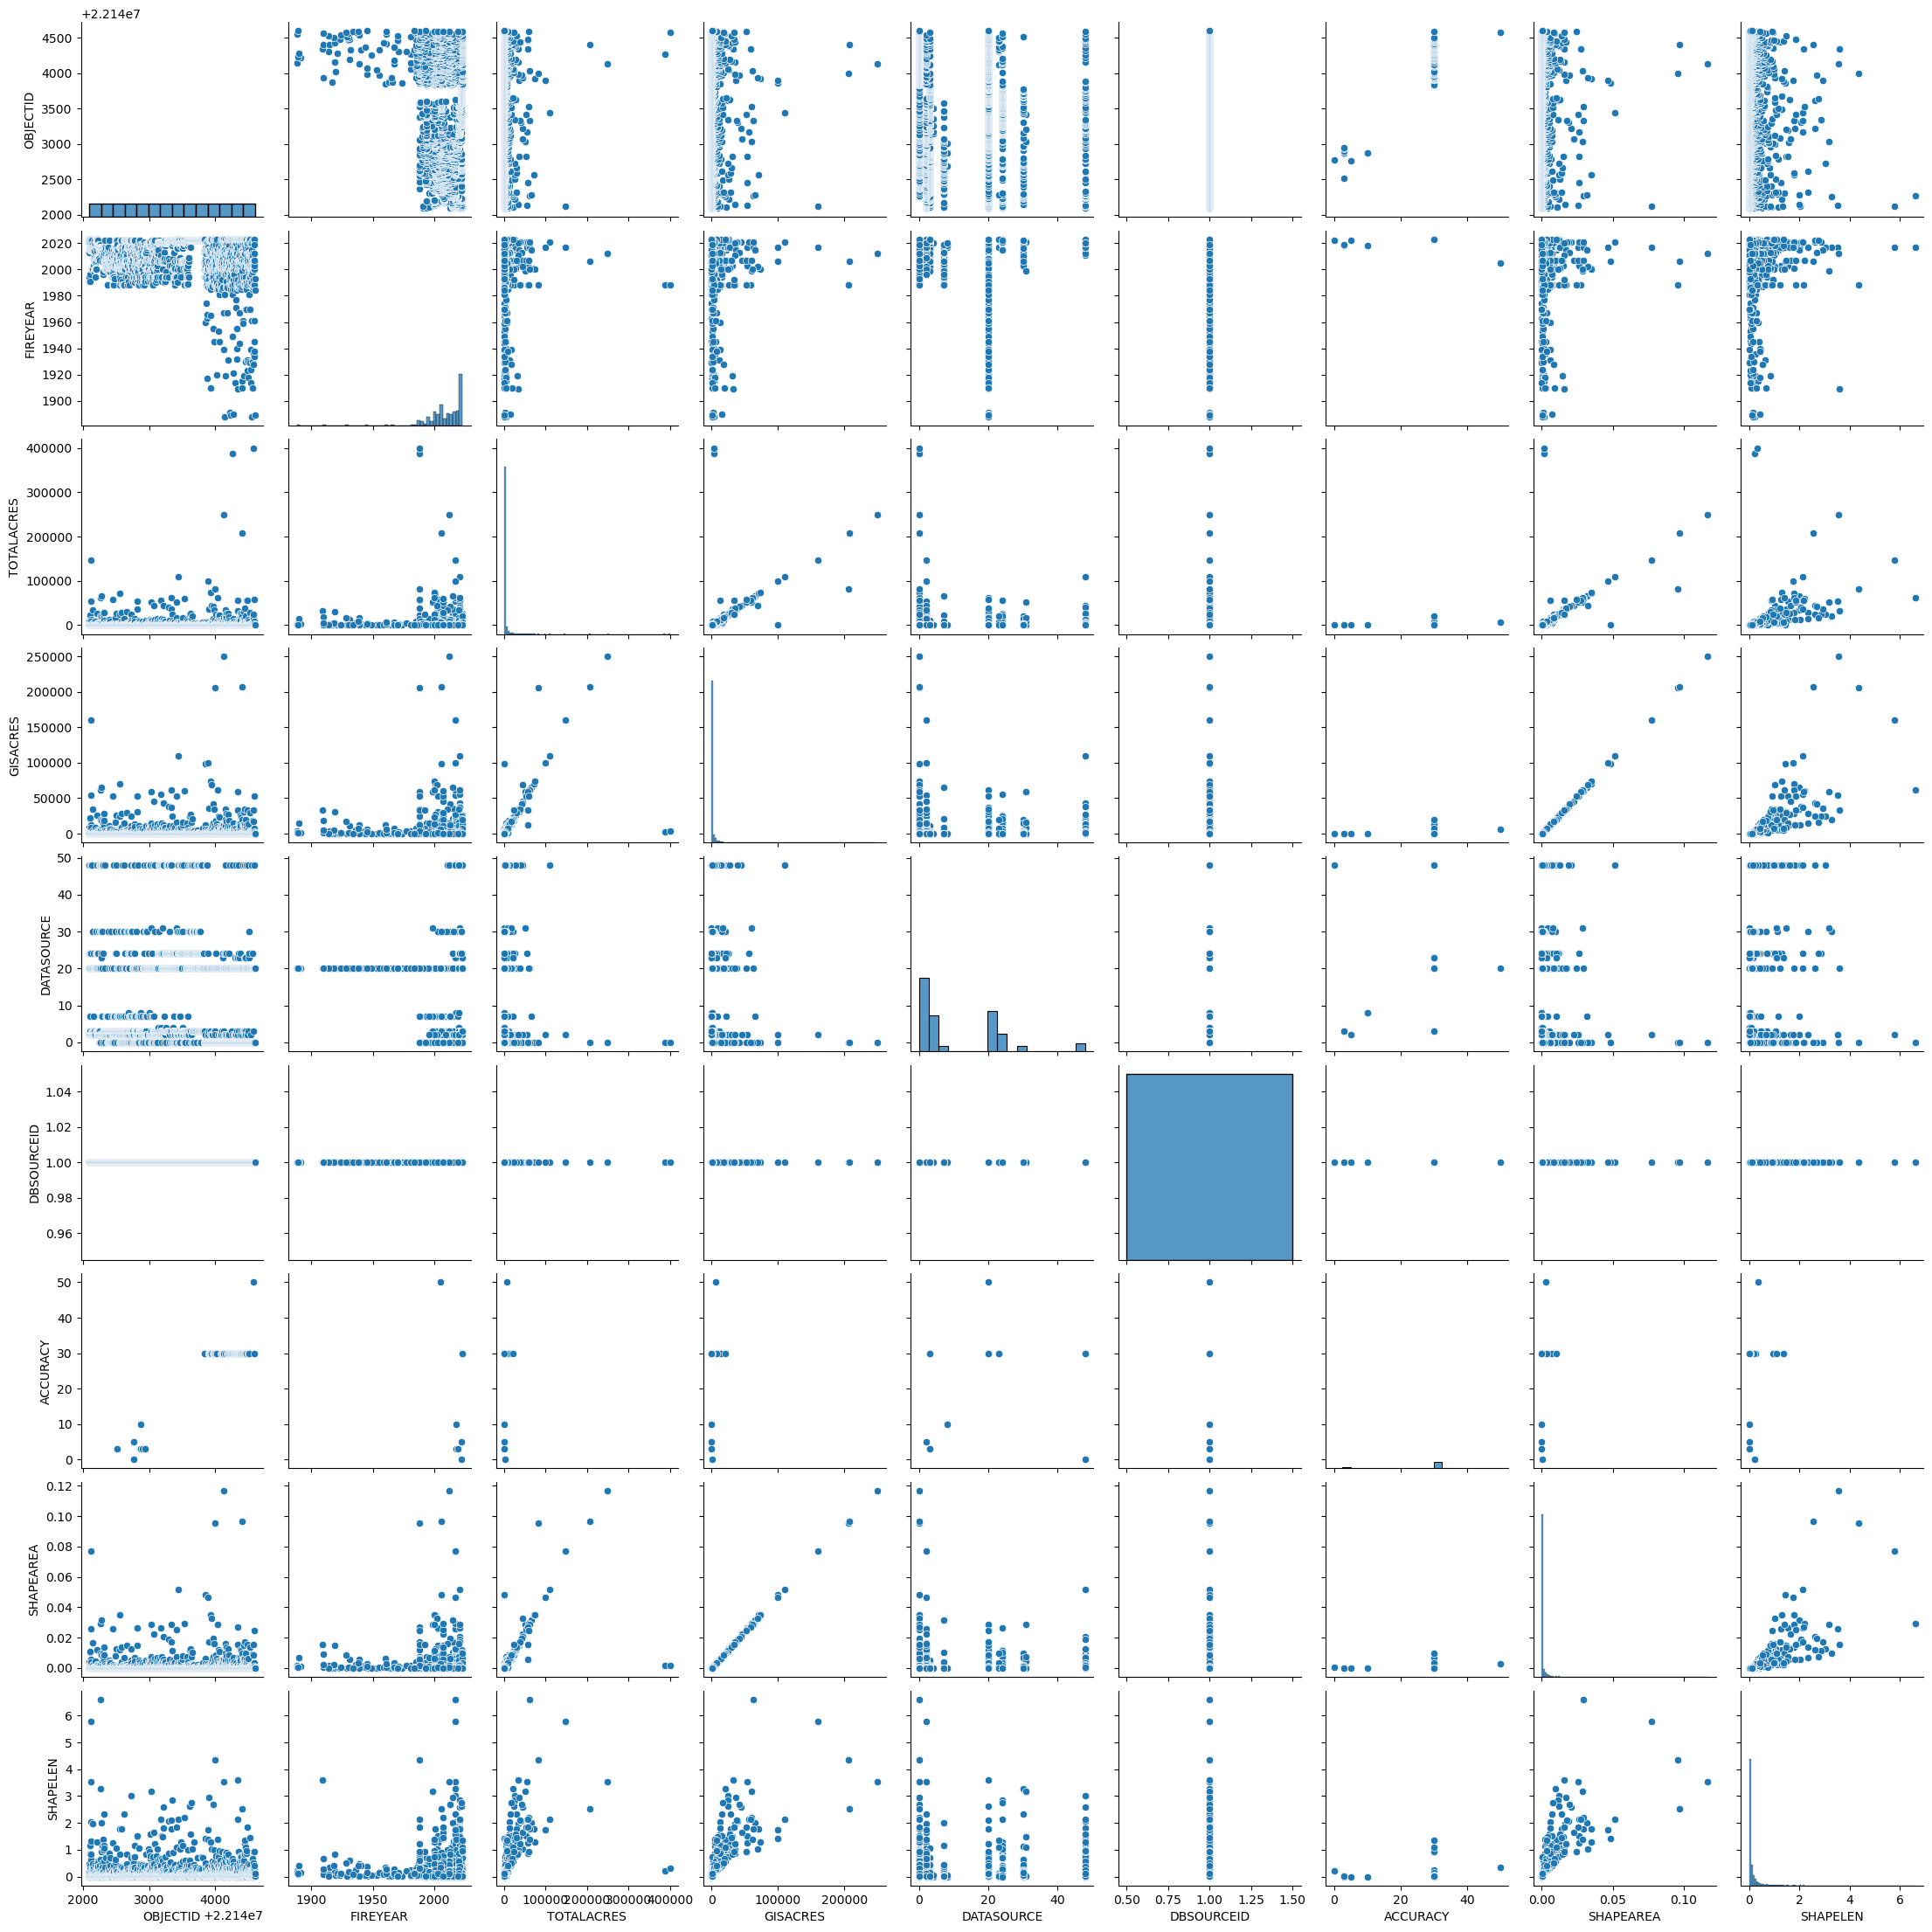

In [50]:
sns.pairplot(df)
plt.show()

In [51]:
# drop PRE_ID and POST_ID if they exist
df.drop(columns=['PRE_ID', 'POST_ID'], errors='ignore', inplace=True)
print("Columns now:", list(df.columns))

Columns now: ['OBJECTID', 'GLOBALID', 'FIREOCCURID', 'CN', 'REVDATE', 'FIRENAME', 'COMPLEXNAME', 'FIREYEAR', 'UNIQFIREID', 'SOFIRENUM', 'LOCALFIRENUM', 'SECURITYID', 'DISCOVERYDATETIME', 'TOTALACRES', 'GISACRES', 'SIZECLASS', 'STATCAUSE', 'COMMENTS', 'DATASOURCE', 'PERIMETERDATETIME', 'OWNERAGENCY', 'UNITIDOWNER', 'PROTECTIONAGENCY', 'UNITIDPROTECT', 'FEATURECAT', 'FIRERPTQC', 'DBSOURCEID', 'DBSOURCEDATE', 'ACCURACY', 'SHAPEAREA', 'SHAPELEN']


Correlations with SHAPELEN:
 SHAPELEN      1.000000
SHAPEAREA     0.768178
GISACRES      0.764765
TOTALACRES    0.520077
ACCURACY      0.097978
DATASOURCE    0.083842
OBJECTID      0.009040
FIREYEAR     -0.035543
DBSOURCEID         NaN
Name: SHAPELEN, dtype: float64

Top correlated numeric pairs (value):
GISACRES    SHAPEAREA    0.999796
OBJECTID    ACCURACY     0.920259
SHAPEAREA   SHAPELEN     0.768178
GISACRES    SHAPELEN     0.764765
TOTALACRES  SHAPEAREA    0.644299
            GISACRES     0.644263
            SHAPELEN     0.520077
FIREYEAR    ACCURACY     0.375643
DATASOURCE  ACCURACY     0.370564
OBJECTID    FIREYEAR    -0.186024
dtype: float64


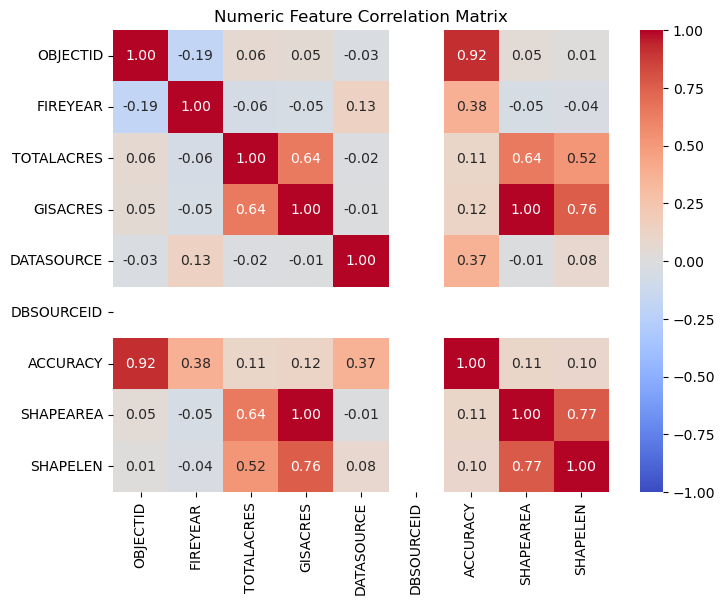

In [52]:
# compute and summarize numeric correlations
num = df.select_dtypes(include=[np.number])
corr = num.corr()

# print correlation of the column in `col` with other numeric features
target = col  # 'SHAPELEN'
if target in corr.columns:
    print(f"Correlations with {target}:\n", corr[target].sort_values(ascending=False))
else:
    print(f"{target} not found among numeric columns.")

# print top pairs by absolute correlation (excluding self-correlations)
au = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
top_pairs = au.stack().reindex(au.stack().abs().sort_values(ascending=False).index)
print("\nTop correlated numeric pairs (value):")
print(top_pairs.head(10))

# visual overview
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Numeric Feature Correlation Matrix")
plt.show()

Top 5 features most linearly correlated with SHAPELEN:
- SHAPEAREA: pearson=0.768
- GISACRES: pearson=0.765
- TOTALACRES: pearson=0.520
- ACCURACY: pearson=0.098
- DATASOURCE: pearson=0.084

Top correlated numeric pairs (overall):
- GISACRES & SHAPEAREA: 1.000
- OBJECTID & ACCURACY: 0.920
- SHAPEAREA & SHAPELEN: 0.768
- GISACRES & SHAPELEN: 0.765
- TOTALACRES & SHAPEAREA: 0.644

Notes:
- Correlation is Pearson (linear) and does not imply causation.
- GISACRES <-> SHAPEAREA (~1.00) suggests a derived/duplicate relationship; drop one to avoid multicollinearity.
- SHAPELEN correlates strongly with SHAPEAREA/GISACRES (0.76–0.77) and moderately with TOTALACRES (0.52).
- OBJECTID correlating with ACCURACY is likely spurious (identifier) and ACCURACY has many missing values; treat with caution.
- Before modeling: handle missing values, check for outliers, and consider variance-inflation or feature selection to mitigate multicollinearity.

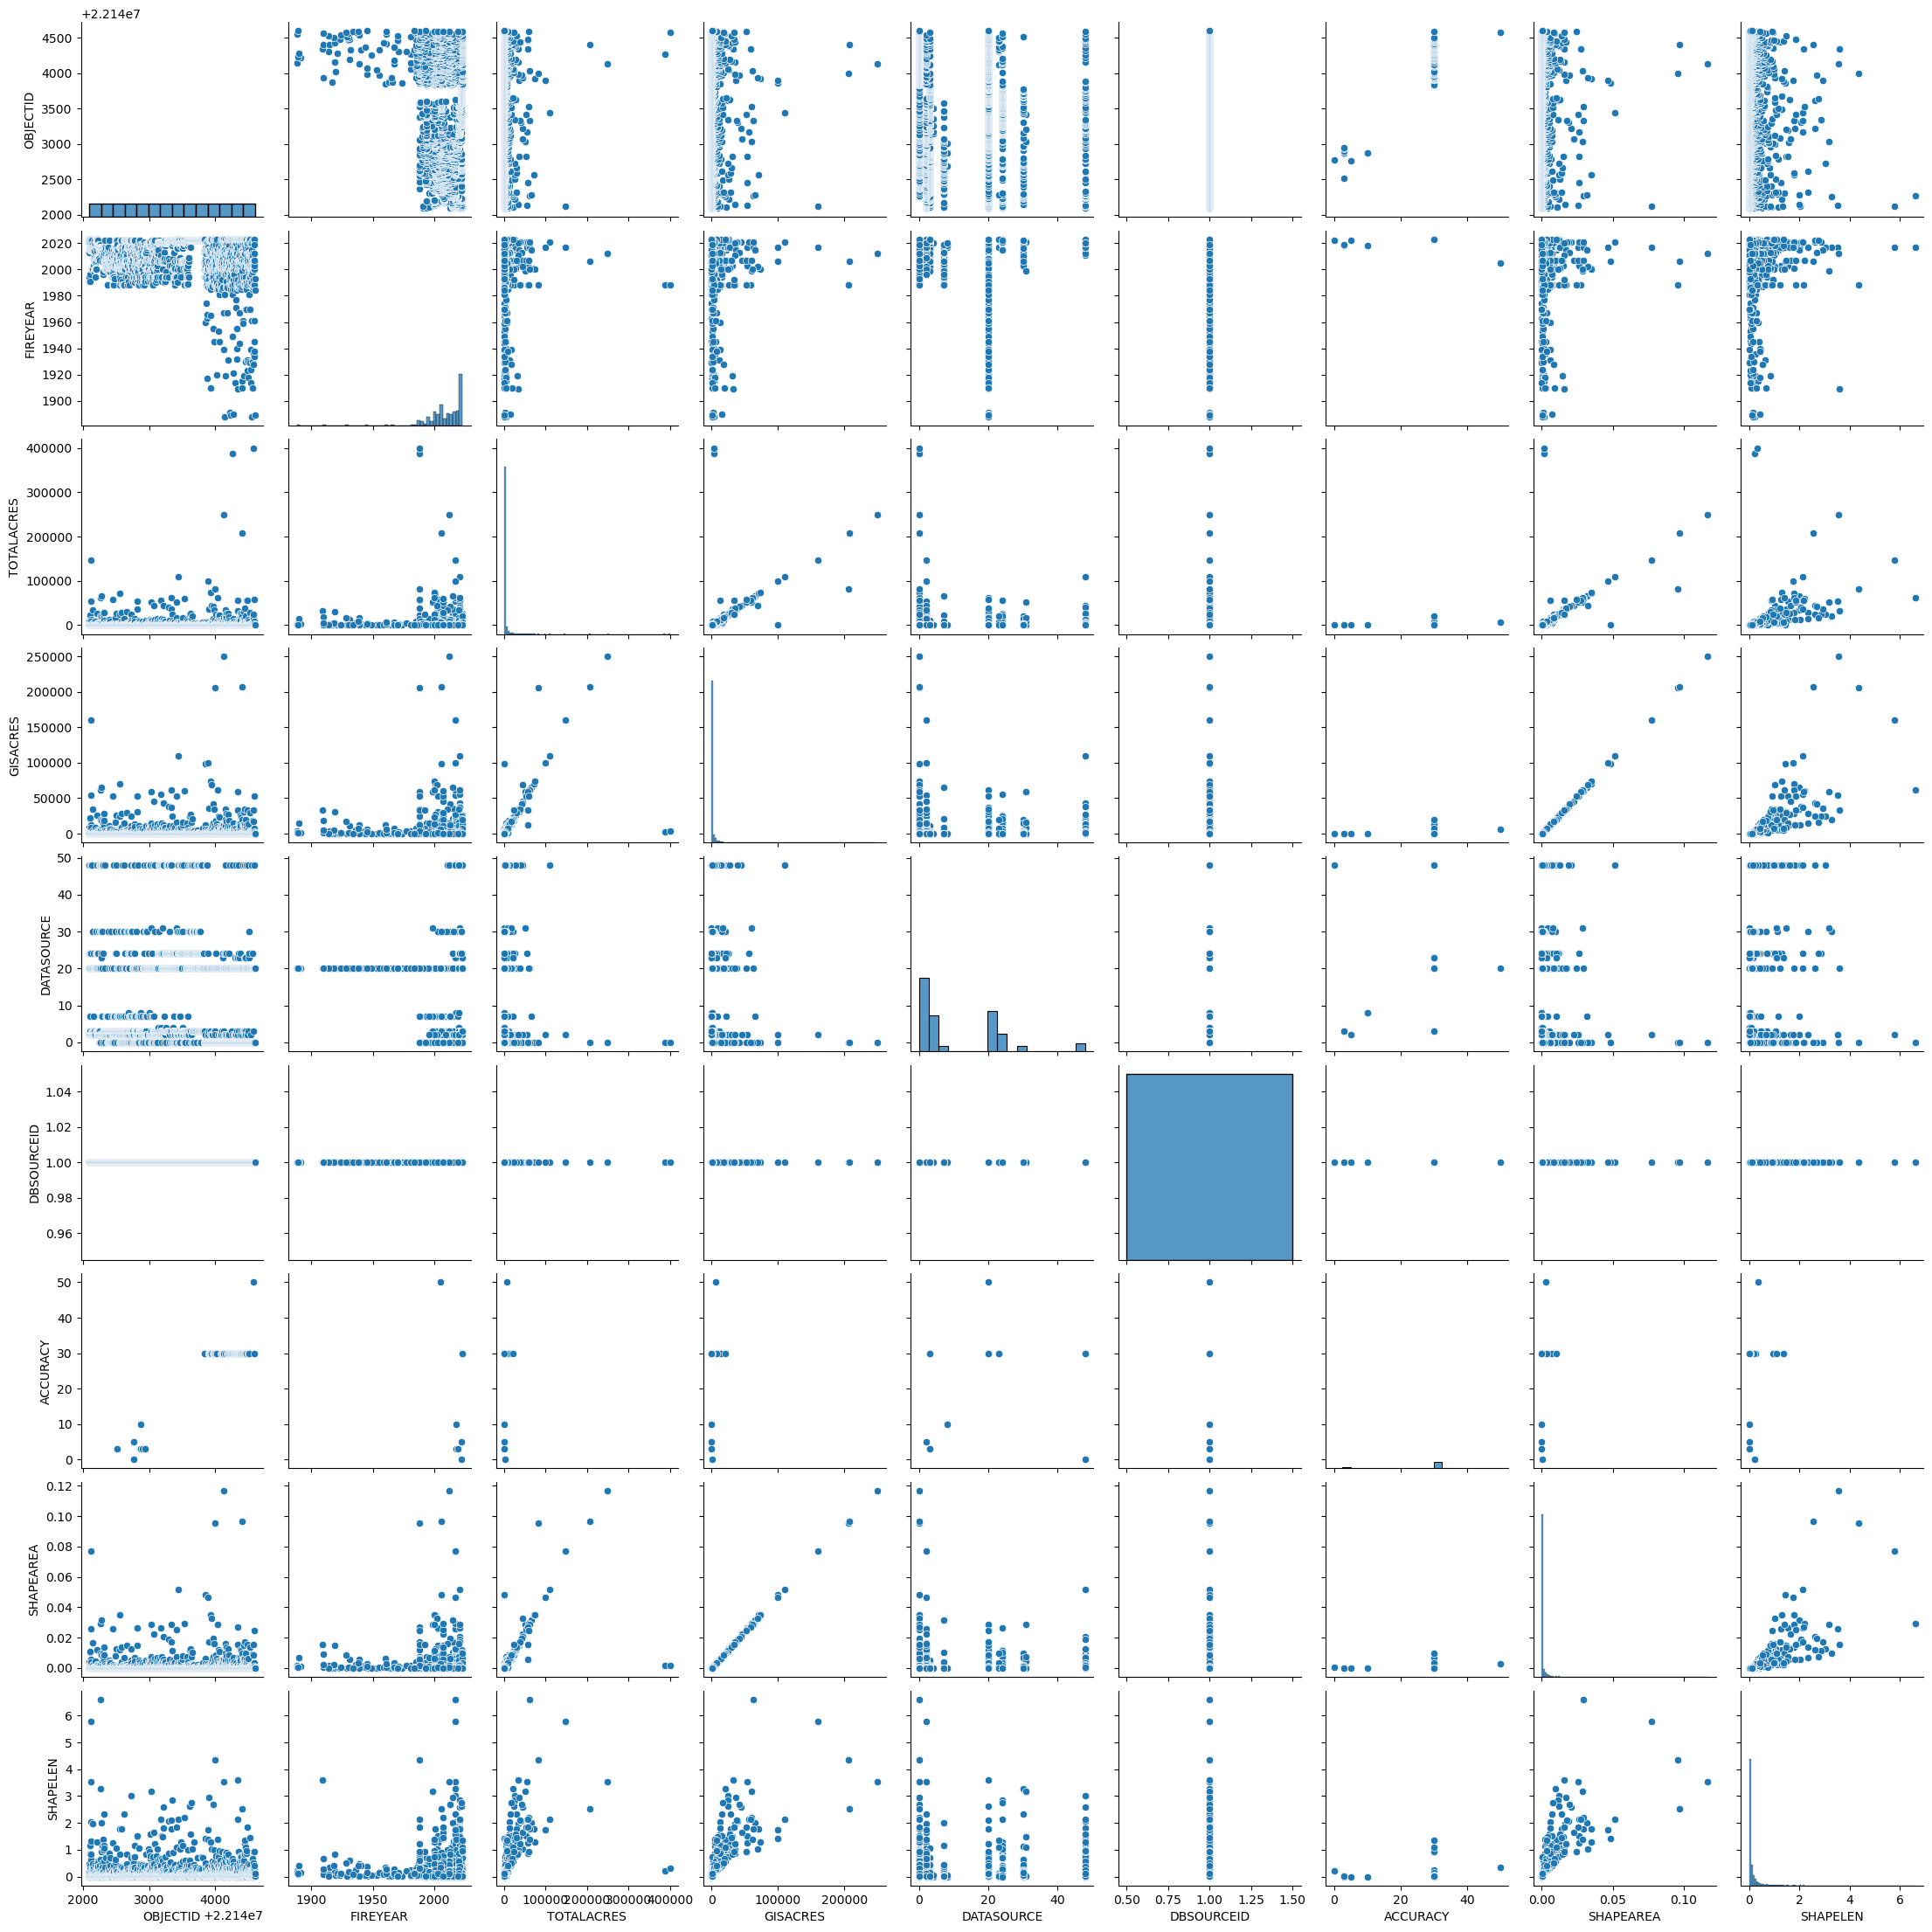

In [53]:
sns.pairplot(df)
plt.show()

In [54]:
# drop specified columns if they exist and update numeric/correlation summaries
cols_to_remove = ['PERIM_ID', 'DNBR_OFFST', 'DNBR_STDDV', 'NODATA_THRESHOLD']
df.drop(columns=cols_to_remove, errors='ignore', inplace=True)
print("Dropped (if present). Columns now:", list(df.columns))

# update numeric dataframe and correlations to reflect removal
num = df.select_dtypes(include=[np.number])
corr = num.corr()

au = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
if not au.stack().empty:
    top_pairs = au.stack().reindex(au.stack().abs().sort_values(ascending=False).index)
else:
    top_pairs = pd.Series(dtype=float)

print("Numeric shape:", num.shape)
print("Top correlated numeric pairs (head):")
print(top_pairs.head(10))

Dropped (if present). Columns now: ['OBJECTID', 'GLOBALID', 'FIREOCCURID', 'CN', 'REVDATE', 'FIRENAME', 'COMPLEXNAME', 'FIREYEAR', 'UNIQFIREID', 'SOFIRENUM', 'LOCALFIRENUM', 'SECURITYID', 'DISCOVERYDATETIME', 'TOTALACRES', 'GISACRES', 'SIZECLASS', 'STATCAUSE', 'COMMENTS', 'DATASOURCE', 'PERIMETERDATETIME', 'OWNERAGENCY', 'UNITIDOWNER', 'PROTECTIONAGENCY', 'UNITIDPROTECT', 'FEATURECAT', 'FIRERPTQC', 'DBSOURCEID', 'DBSOURCEDATE', 'ACCURACY', 'SHAPEAREA', 'SHAPELEN']
Numeric shape: (2500, 9)
Top correlated numeric pairs (head):
GISACRES    SHAPEAREA    0.999796
OBJECTID    ACCURACY     0.920259
SHAPEAREA   SHAPELEN     0.768178
GISACRES    SHAPELEN     0.764765
TOTALACRES  SHAPEAREA    0.644299
            GISACRES     0.644263
            SHAPELEN     0.520077
FIREYEAR    ACCURACY     0.375643
DATASOURCE  ACCURACY     0.370564
OBJECTID    FIREYEAR    -0.186024
dtype: float64


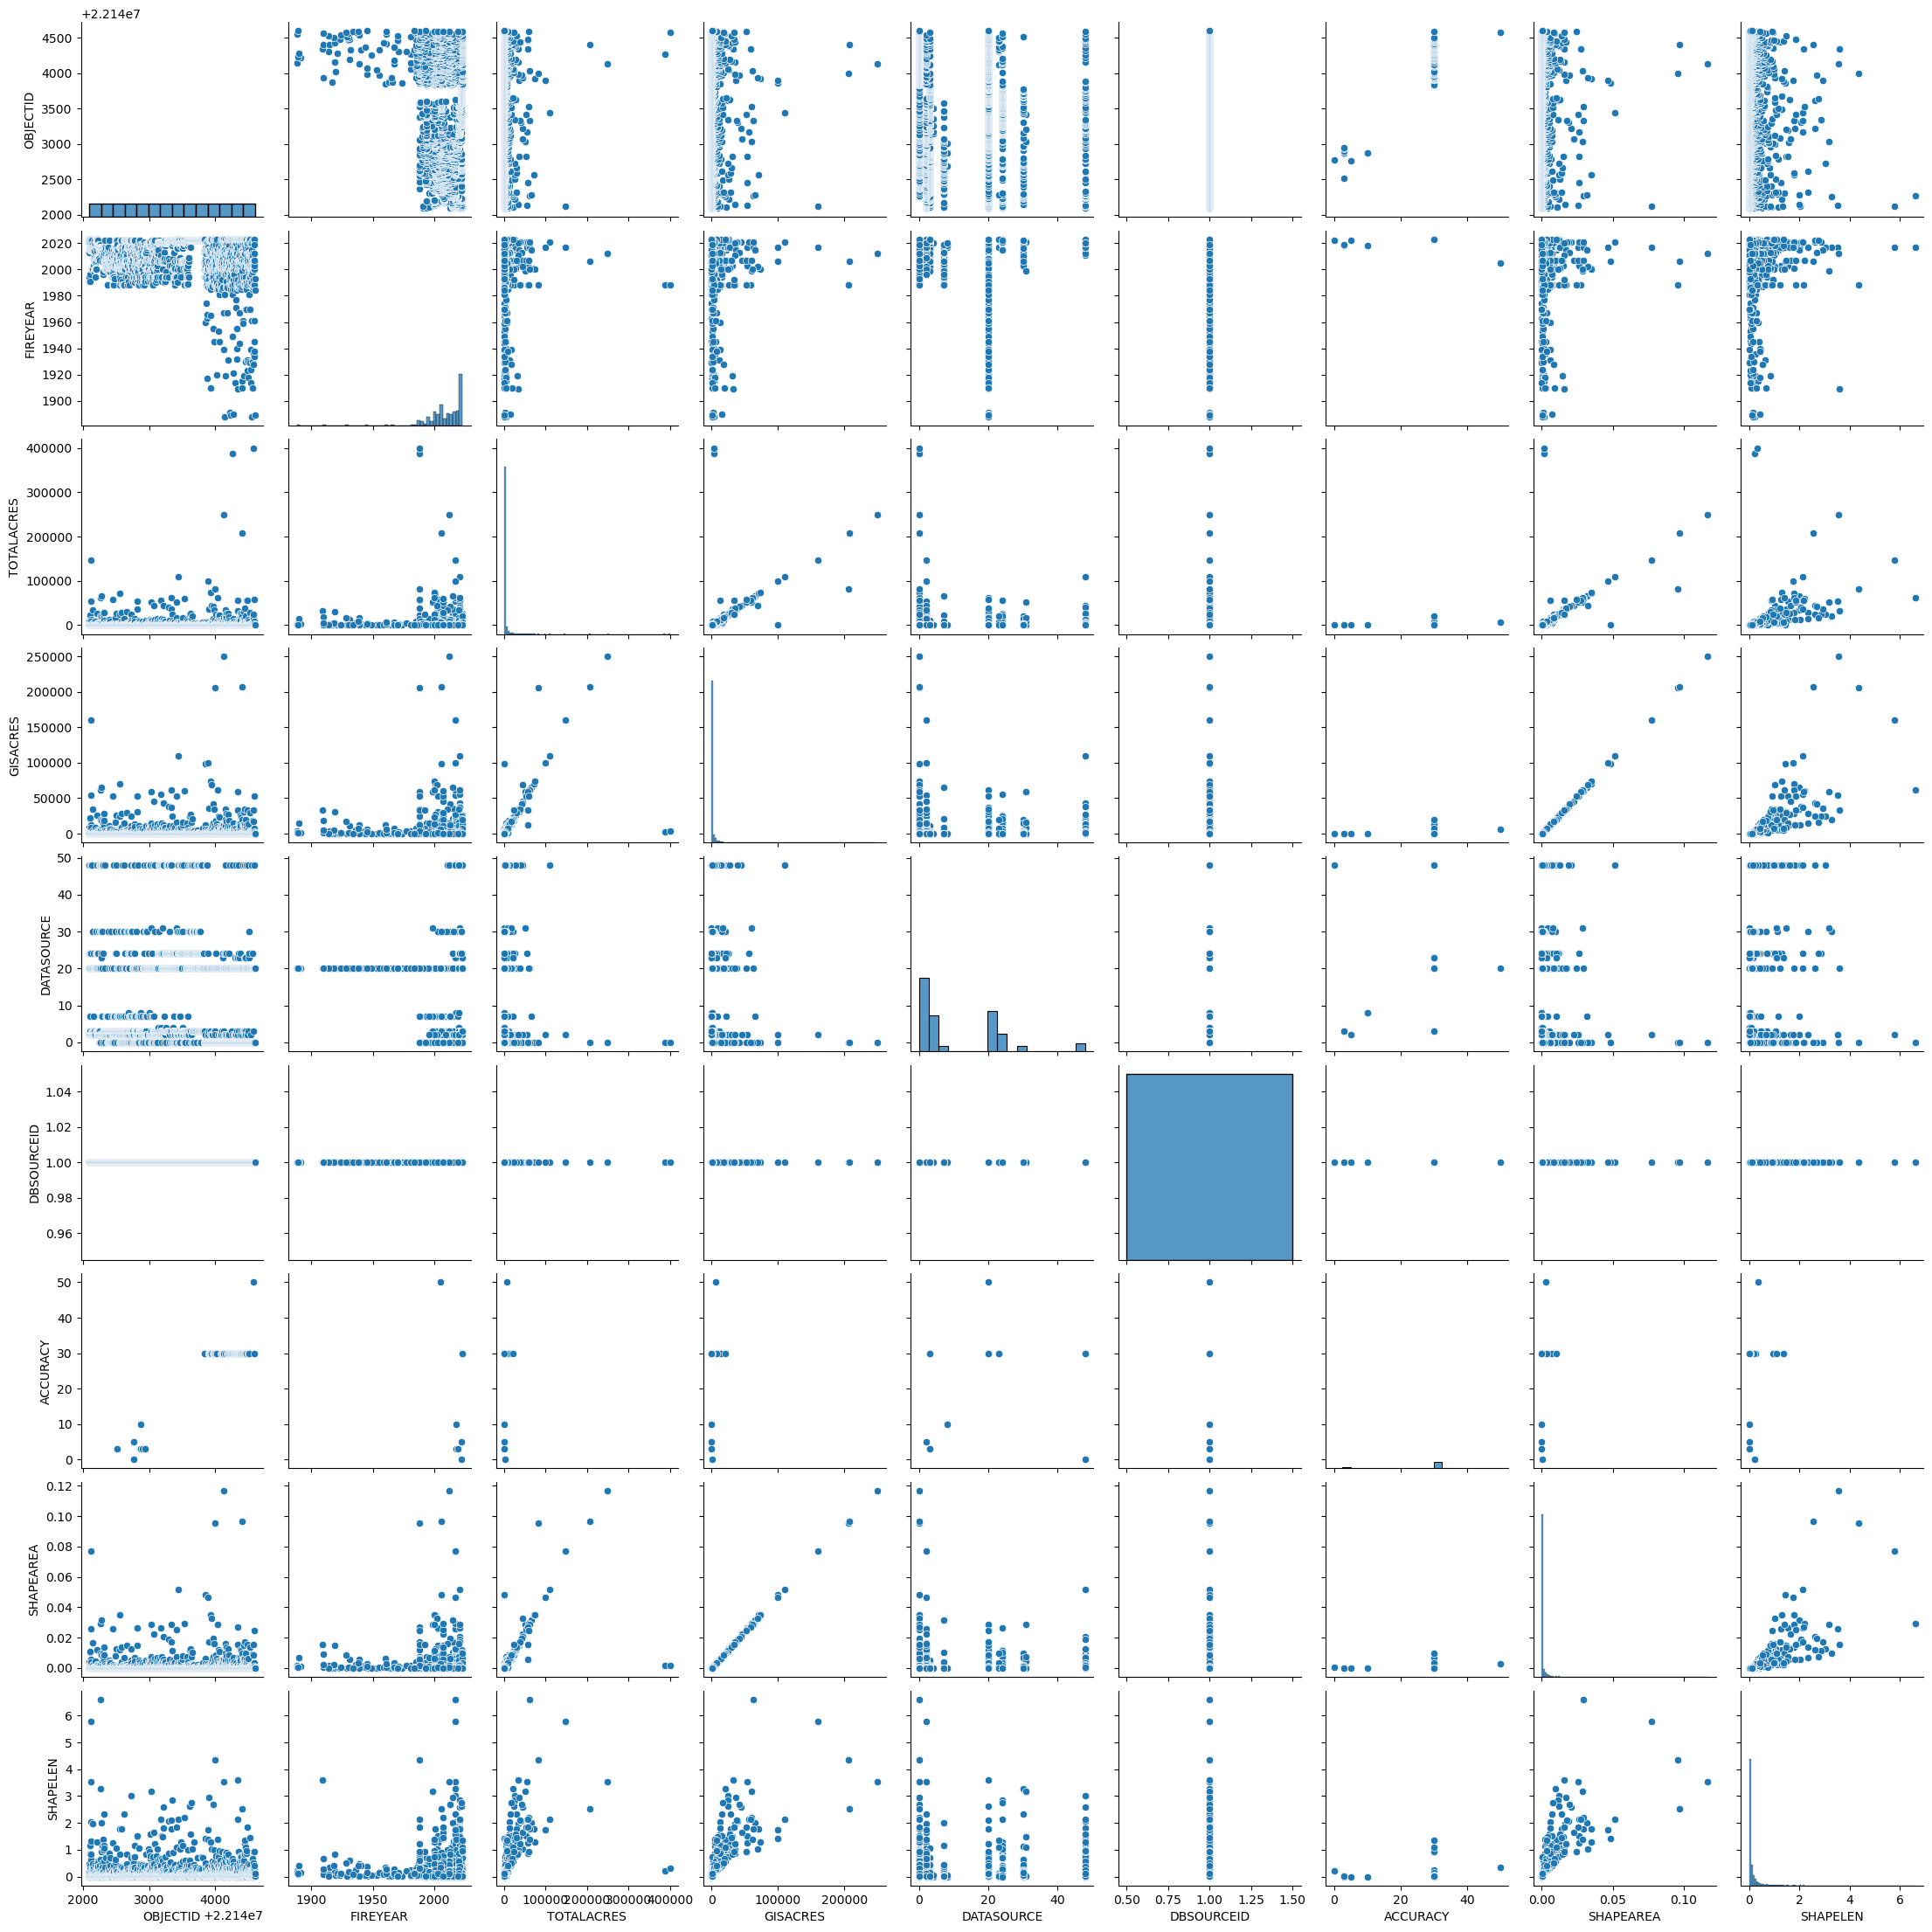

In [55]:
sns.pairplot(df)
plt.show()

Correlation matrix (rounded):
            OBJECTID  FIREYEAR  TOTALACRES  GISACRES  DATASOURCE  DBSOURCEID  \
OBJECTID       1.000    -0.186       0.063     0.048      -0.026         NaN   
FIREYEAR      -0.186     1.000      -0.062    -0.054       0.133         NaN   
TOTALACRES     0.063    -0.062       1.000     0.644      -0.022         NaN   
GISACRES       0.048    -0.054       0.644     1.000      -0.010         NaN   
DATASOURCE    -0.026     0.133      -0.022    -0.010       1.000         NaN   
DBSOURCEID       NaN       NaN         NaN       NaN         NaN         NaN   
ACCURACY       0.920     0.376       0.109     0.118       0.371         NaN   
SHAPEAREA      0.046    -0.054       0.644     1.000      -0.010         NaN   
SHAPELEN       0.009    -0.036       0.520     0.765       0.084         NaN   

            ACCURACY  SHAPEAREA  SHAPELEN  
OBJECTID       0.920      0.046     0.009  
FIREYEAR       0.376     -0.054    -0.036  
TOTALACRES     0.109      0.644     0

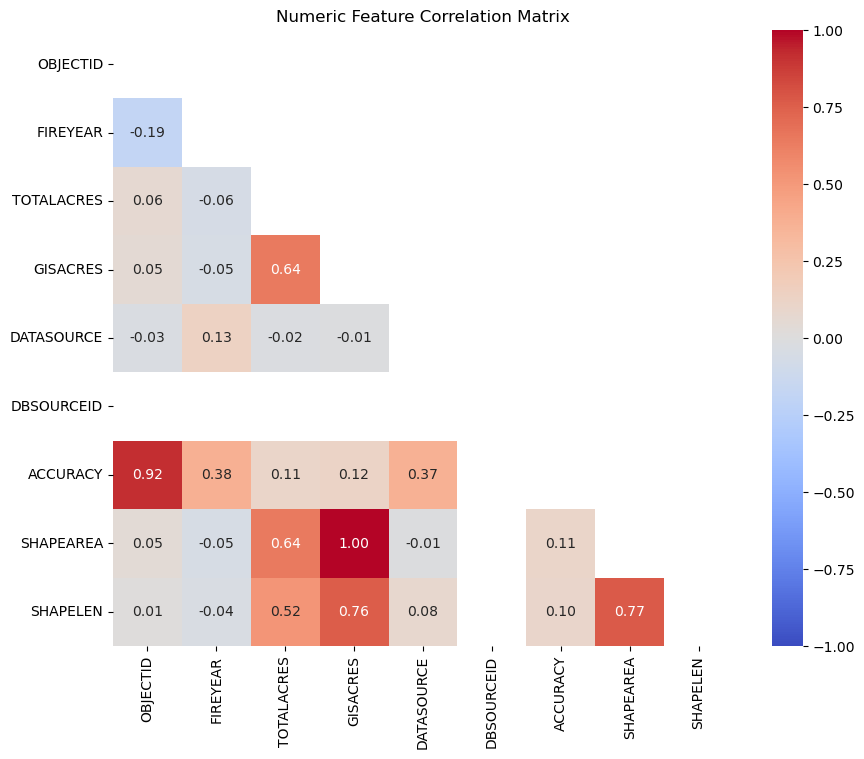


Top correlated numeric pairs (by absolute value):
GISACRES    SHAPEAREA    0.999796
OBJECTID    ACCURACY     0.920259
SHAPEAREA   SHAPELEN     0.768178
GISACRES    SHAPELEN     0.764765
TOTALACRES  SHAPEAREA    0.644299
            GISACRES     0.644263
            SHAPELEN     0.520077
FIREYEAR    ACCURACY     0.375643
DATASOURCE  ACCURACY     0.370564
OBJECTID    FIREYEAR    -0.186024
dtype: float64

Correlations with SHAPELEN:
SHAPELEN      1.000
SHAPEAREA     0.768
GISACRES      0.765
TOTALACRES    0.520
ACCURACY      0.098
DATASOURCE    0.084
OBJECTID      0.009
FIREYEAR     -0.036
DBSOURCEID      NaN
Name: SHAPELEN, dtype: float64


In [56]:
# display correlation matrix and top correlated pairs
# (uses existing df, corr, top_pairs, target/col if present)
if 'corr' not in globals():
    num = df.select_dtypes(include=[np.number])
    corr = num.corr()

print("Correlation matrix (rounded):")
print(corr.round(3))

plt.figure(figsize=(10,8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Numeric Feature Correlation Matrix")
plt.show()

if 'top_pairs' in globals():
    print("\nTop correlated numeric pairs (by absolute value):")
    print(top_pairs.head(10))

t = globals().get('target') or globals().get('col') or globals().get('c') or globals().get('i')
if t and t in corr.columns:
    print(f"\nCorrelations with {t}:")
    print(corr[t].sort_values(ascending=False).round(3))

In [57]:
x = df.drop(columns=[target], errors='ignore')
y = df[target] if target in df.columns else None

### Decison tree models

Test MSE: 0.02900692736752688
Test R2: 0.7375234565861992

Feature importances:
 TOTALACRES    0.5754
SHAPEAREA     0.3450
FIREYEAR      0.0566
DATASOURCE    0.0230

5-fold CV R2: 0.6930 ± 0.0985


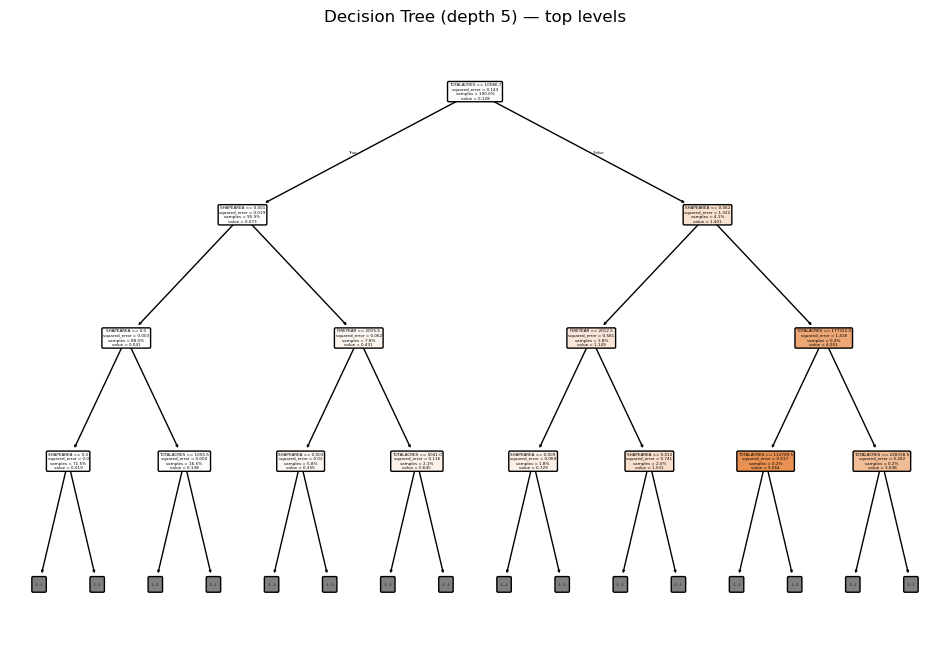

In [67]:
# train a DecisionTreeRegressor on numeric data (uses existing temp_num and target)
X = temp_num.drop(columns=[target], errors='ignore').fillna(temp_num.mean())
y = temp_num[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Test R2:", r2_score(y_test, y_pred))

# feature importances
fi = pd.Series(dt.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nFeature importances:\n", fi.round(4).to_string())

# 5-fold CV R2
cv_r2 = cross_val_score(DecisionTreeRegressor(max_depth=5, random_state=42), X, y, cv=5, scoring='r2', n_jobs=-1)
print("\n5-fold CV R2: %.4f ± %.4f" % (cv_r2.mean(), cv_r2.std()))

# optional: visualize tree (shallow view)
plt.figure(figsize=(12,8))
tree.plot_tree(dt, feature_names=X.columns, filled=True, rounded=True, proportion=True, max_depth=3)
plt.title("Decision Tree (depth 5) — top levels")
plt.show()

Tree depth: 5
Number of leaves: 28
Number of nodes: 55

Decision rules:

|--- TOTALACRES <= 10586.700
|   |--- SHAPEAREA <= 0.001
|   |   |--- SHAPEAREA <= 0.000
|   |   |   |--- SHAPEAREA <= 0.000
|   |   |   |   |--- SHAPEAREA <= 0.000
|   |   |   |   |   |--- value: [0.004]
|   |   |   |   |--- SHAPEAREA >  0.000
|   |   |   |   |   |--- value: [0.018]
|   |   |   |--- SHAPEAREA >  0.000
|   |   |   |   |--- TOTALACRES <= 154.500
|   |   |   |   |   |--- value: [0.039]
|   |   |   |   |--- TOTALACRES >  154.500
|   |   |   |   |   |--- value: [0.066]
|   |   |--- SHAPEAREA >  0.000
|   |   |   |--- TOTALACRES <= 1055.500
|   |   |   |   |--- SHAPEAREA <= 0.000
|   |   |   |   |   |--- value: [0.097]
|   |   |   |   |--- SHAPEAREA >  0.000
|   |   |   |   |   |--- value: [0.137]
|   |   |   |--- TOTALACRES >  1055.500
|   |   |   |   |--- FIREYEAR <= 2015.500
|   |   |   |   |   |--- value: [0.177]
|   |   |   |   |--- FIREYEAR >  2015.500
|   |   |   |   |   |--- value: [0.241]
|   

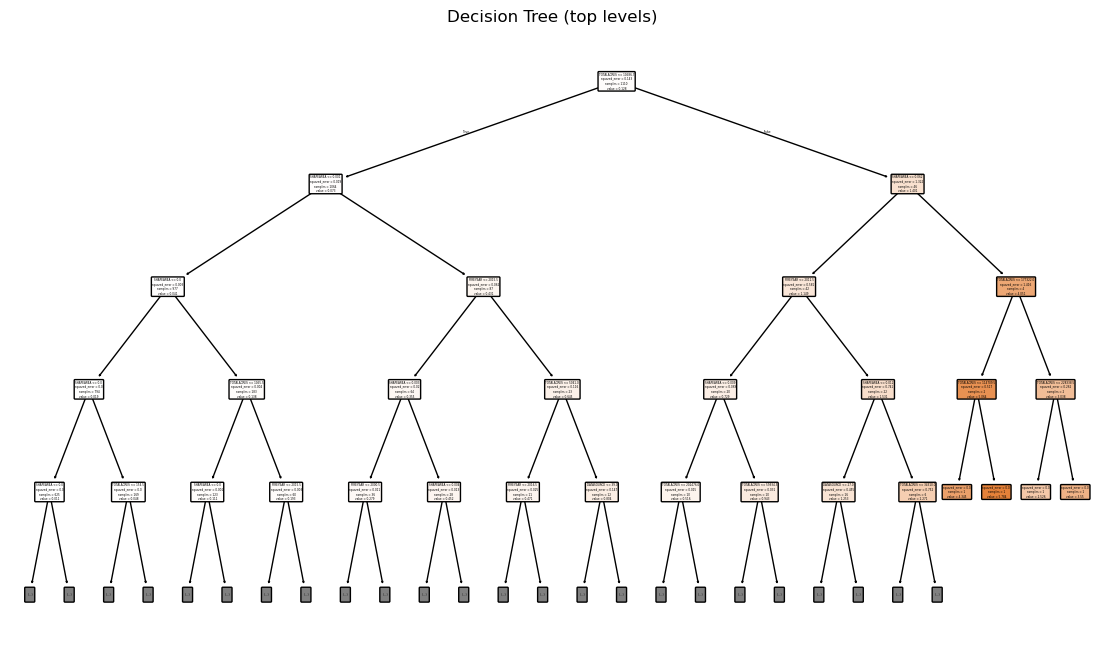

In [68]:
from sklearn.tree import export_text, DecisionTreeRegressor
import pandas as pd

# Decision tree breakdown (use existing fitted `dt` if available; otherwise fit a new shallow tree)
import matplotlib.pyplot as plt

# choose or fit model
model = globals().get('dt', None)
def _is_fitted(m):
    return m is not None and hasattr(m, "tree_")

if not _is_fitted(model):
    if 'X_train' in globals() and 'y_train' in globals():
        X_tr, y_tr = X_train, y_train
    elif 'X_full' in globals() and 'y_full' in globals():
        X_tr, y_tr = X_full, y_full
    elif 'X_use' in globals() and globals().get('y_use') is not None:
        X_tr, y_tr = X_use, y_use
    else:
        raise RuntimeError("No fitted DecisionTree and no training data found to fit one.")
    model = DecisionTreeRegressor(max_depth=5, random_state=42)
    model.fit(X_tr, y_tr)

# feature names resolution
if hasattr(model, "feature_names_in_"):
    feat_names = list(model.feature_names_in_)
else:
    if 'X_train' in globals():
        feat_names = list(X_train.columns)
    elif 'X_full' in globals():
        feat_names = list(X_full.columns)
    elif 'X_use' in globals():
        feat_names = list(X_use.columns)
    else:
        feat_names = None

# summary stats
print("Tree depth:", model.get_depth())
print("Number of leaves:", model.get_n_leaves())
if hasattr(model, "tree_"):
    print("Number of nodes:", model.tree_.node_count)

# textual rules
print("\nDecision rules:\n")
print(export_text(model, feature_names=feat_names, decimals=3))

# feature importances
if hasattr(model, "feature_importances_") and feat_names is not None:
    fi = pd.Series(model.feature_importances_, index=feat_names).sort_values(ascending=False)
    print("\nFeature importances:\n", fi.round(4).to_string())

# visual (top levels)
plt.figure(figsize=(14,8))
tree.plot_tree(model, feature_names=feat_names, filled=True, rounded=True, max_depth=4)
plt.title("Decision Tree (top levels)")
plt.show()

In [58]:
clf = tree.DecisionTreeClassifier() #instantiate Decision Tree class

### Random forest model

In [69]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score
import pandas as pd

# prepare features/target (prefer X_use/y_use if available)
if 'X_use' in globals() and 'y_use' in globals() and X_use is not None and y_use is not None:
	X, y = X_use.copy(), y_use.copy()
elif 'X_full' in globals() and 'y_full' in globals():
	X, y = X_full.copy(), y_full.copy()
else:
	X = temp_num.drop(columns=[target], errors='ignore').fillna(temp_num.mean())
	y = temp_num[target].copy()

# ensure train/test split
if 'X_train' not in globals() or 'X_test' not in globals() or 'y_train' not in globals() or 'y_test' not in globals():
	X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# train Random Forest
rf = RandomForestRegressor(n_estimators=200, max_depth=7, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# evaluate
y_pred = rf.predict(X_test)
print(f"RandomForest: MSE={mean_squared_error(y_test, y_pred):.6f}, R2={r2_score(y_test, y_pred):.4f}")

# feature importances
fi = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("\nTop feature importances:\n", fi.head(10).round(4).to_string())

# 5-fold CV (R2)
cv_r2 = cross_val_score(rf, X, y, cv=5, scoring='r2', n_jobs=-1)
print("\n5-fold CV R2: %.4f ± %.4f" % (cv_r2.mean(), cv_r2.std()))

RandomForest: MSE=0.022295, R2=0.7983

Top feature importances:
 SHAPEAREA     0.6833
TOTALACRES    0.2191
DATASOURCE    0.0505
FIREYEAR      0.0470

5-fold CV R2: 0.7438 ± 0.0536


##### Exploratory analysis shows near‑perfect redundancy between GISACRES and SHAPEAREA (≈1.0) and strong correlations of SHAPELEN with SHAPEAREA/GISACRES (~0.76) and a moderate relationship with TOTALACRES (~0.52), indicating the shape/area metrics dominate the signal and create multicollinearity. OBJECTID correlates strongly with ACCURACY (≈0.92) but ACCURACY is sparsely populated, so that relationship is likely a dataset artifact. DBSOURCEID and a few other fields contain many missing values and should be dropped or carefully imputed. A decision tree regressor confirms SHAPEAREA (and GISACRES) as the most important predictors for SHAPELEN, so remove duplicate area features, handle missing data, inspect outliers, and validate with cross‑validation or regularized models to avoid overfitting

In [59]:
# drop identifier, sparse, duplicate and free-text columns identified in analysis
cols_to_drop = ['OBJECTID', 'GLOBALID', 'FIREOCCURID', 'UNIQFIREID',
                'DBSOURCEID', 'ACCURACY', 'GISACRES', 'COMMENTS']
df.drop(columns=cols_to_drop, errors='ignore', inplace=True)

print("Dropped (if present):", cols_to_drop)
print("Columns now:", list(df.columns))
print("Target present:", 'SHAPELEN' in df.columns)

# update numeric/data summaries used later
num = df.select_dtypes(include=[np.number])
temp_num = num.copy()
corr = num.corr()

au = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
top_pairs = au.stack().reindex(au.stack().abs().sort_values(ascending=False).index) if not au.stack().empty else pd.Series(dtype=float)

print("Numeric shape:", num.shape)
print("Top correlated numeric pairs (head):")
print(top_pairs.head(10))

Dropped (if present): ['OBJECTID', 'GLOBALID', 'FIREOCCURID', 'UNIQFIREID', 'DBSOURCEID', 'ACCURACY', 'GISACRES', 'COMMENTS']
Columns now: ['CN', 'REVDATE', 'FIRENAME', 'COMPLEXNAME', 'FIREYEAR', 'SOFIRENUM', 'LOCALFIRENUM', 'SECURITYID', 'DISCOVERYDATETIME', 'TOTALACRES', 'SIZECLASS', 'STATCAUSE', 'DATASOURCE', 'PERIMETERDATETIME', 'OWNERAGENCY', 'UNITIDOWNER', 'PROTECTIONAGENCY', 'UNITIDPROTECT', 'FEATURECAT', 'FIRERPTQC', 'DBSOURCEDATE', 'SHAPEAREA', 'SHAPELEN']
Target present: True
Numeric shape: (2500, 5)
Top correlated numeric pairs (head):
SHAPEAREA   SHAPELEN      0.768178
TOTALACRES  SHAPEAREA     0.644299
            SHAPELEN      0.520077
FIREYEAR    DATASOURCE    0.132856
DATASOURCE  SHAPELEN      0.083842
FIREYEAR    TOTALACRES   -0.062393
            SHAPEAREA    -0.053956
            SHAPELEN     -0.035543
TOTALACRES  DATASOURCE   -0.021726
DATASOURCE  SHAPEAREA    -0.009672
dtype: float64


In [60]:
# remove exact duplicate rows then deduplicate on common identifier columns if present
before = len(df)
dup_exact = df.duplicated().sum()
df.drop_duplicates(inplace=True)
after = len(df)
print(f"Exact duplicate rows removed: {dup_exact} (rows {before} -> {after})")

# deduplicate by likely identifier columns (keep first occurrence)
id_cols = ['UNIQFIREID', 'GLOBALID', 'CN', 'OBJECTID']
for col in id_cols:
    if col in df.columns:
        before_col = len(df)
        df.drop_duplicates(subset=[col], keep='first', inplace=True)
        removed_col = before_col - len(df)
        if removed_col:
            print(f"Removed {removed_col} duplicate rows based on '{col}'")

# update numeric summaries used downstream
num = df.select_dtypes(include=[np.number])
temp_num = num.copy()
corr = num.corr()

au = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
top_pairs = au.stack().reindex(au.stack().abs().sort_values(ascending=False).index) if not au.stack().empty else pd.Series(dtype=float)

print("New shape:", df.shape)
print("Top correlated numeric pairs (head):")
print(top_pairs.head(10))

Exact duplicate rows removed: 0 (rows 2500 -> 2500)
Removed 1112 duplicate rows based on 'CN'
New shape: (1388, 23)
Top correlated numeric pairs (head):
SHAPEAREA   SHAPELEN      0.787445
TOTALACRES  SHAPEAREA     0.695450
            SHAPELEN      0.560785
FIREYEAR    DATASOURCE    0.138635
DATASOURCE  SHAPELEN      0.086073
FIREYEAR    TOTALACRES   -0.045617
            SHAPEAREA    -0.031126
TOTALACRES  DATASOURCE   -0.020460
FIREYEAR    SHAPELEN      0.019208
DATASOURCE  SHAPEAREA    -0.015824
dtype: float64


### Cross-Validation for model

In [62]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_validate
import numpy as np

# cross-validation for regression (fix undefined names and use existing temp_num/target)

# prepare features/target from temp_num
X = temp_num.drop(columns=[target], errors='ignore').fillna(temp_num.mean())
y_reg = temp_num[target].copy()

dt_cv = DecisionTreeRegressor(max_depth=5, random_state=42)
scoring = ['r2', 'neg_mean_squared_error']

cv5 = cross_validate(dt_cv, X, y_reg, cv=5, scoring=scoring, n_jobs=-1)
r2_5 = cv5['test_r2']
rmse_5 = np.sqrt(-cv5['test_neg_mean_squared_error'])
print("5-fold CV -- R2: %.3f ± %.3f | RMSE: %.4f ± %.4f" % (r2_5.mean(), r2_5.std(), rmse_5.mean(), rmse_5.std()))
print("5-fold R2 per fold:", r2_5)

cv10 = cross_validate(dt_cv, X, y_reg, cv=10, scoring=scoring, n_jobs=-1)
r2_10 = cv10['test_r2']
rmse_10 = np.sqrt(-cv10['test_neg_mean_squared_error'])
print("10-fold CV - R2: %.3f ± %.3f | RMSE: %.4f ± %.4f" % (r2_10.mean(), r2_10.std(), rmse_10.mean(), rmse_10.std()))
print("10-fold R2 per fold:", r2_10)

5-fold CV -- R2: 0.693 ± 0.098 | RMSE: 0.1886 ± 0.0591
5-fold R2 per fold: [0.79670511 0.70654892 0.55374342 0.60929353 0.79851322]
10-fold CV - R2: 0.651 ± 0.151 | RMSE: 0.1803 ± 0.0501
10-fold R2 per fold: [0.84842182 0.57994503 0.49739938 0.70664508 0.66735724 0.55314508
 0.39547655 0.84697234 0.57277888 0.84260863]


In [ ]:
# compact: compare original feature correlations with CV-predicted correlations
df_cv = pd.concat([X.reset_index(drop=True), pd.Series(y_cv_pred, name='y_cv_pred')], axis=1)
corr_cv = df_cv.corr()
orig = pd.concat([X.reset_index(drop=True), y_reg.reset_index(drop=True)], axis=1)
orig_corr = orig.corr()

comp = pd.DataFrame({
    'orig_corr': orig_corr[y_reg.name].reindex(corr_cv.columns.drop('y_cv_pred')),
    'cv_corr': corr_cv['y_cv_pred'].drop('y_cv_pred')
}).dropna()
comp['abs_change'] = (comp['cv_corr'] - comp['orig_corr']).abs()
print(comp.sort_values('abs_change', ascending=False).round(4))

            orig_corr  cv_corr  abs_change
TOTALACRES     0.5201   0.5534      0.0333
FIREYEAR      -0.0355  -0.0602      0.0246
SHAPEAREA      0.7682   0.7787      0.0106
GISACRES       0.7648   0.7741      0.0093
DATASOURCE     0.0838   0.0789      0.0049
ACCURACY       0.0980   0.0952      0.0028


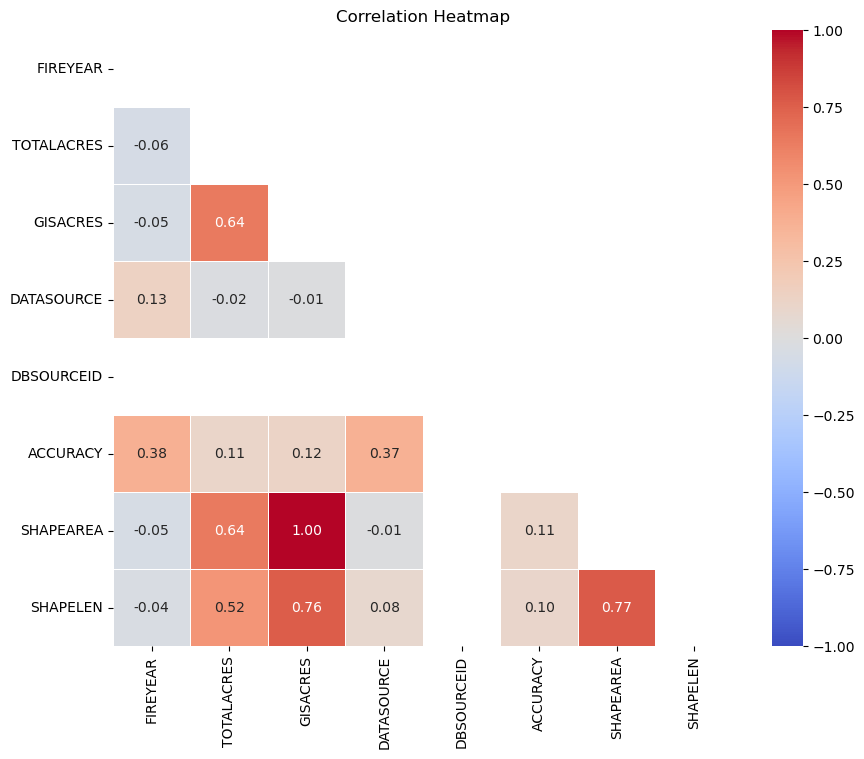

In [ ]:
# use existing corr_ref if available, otherwise compute from df
corr = globals().get('corr_ref') if 'corr_ref' in globals() else df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(10,8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
df.head(12)

,CN,REVDATE,FIRENAME,COMPLEXNAME,FIREYEAR,SOFIRENUM,LOCALFIRENUM,SECURITYID,DISCOVERYDATETIME,TOTALACRES,...,PERIMETERDATETIME,OWNERAGENCY,UNITIDOWNER,PROTECTIONAGENCY,UNITIDPROTECT,FEATURECAT,FIRERPTQC,DBSOURCEDATE,SHAPEAREA,SHAPELEN
0,1686796,2022/06/02 00:00:00+00,Stump,NaN,2013,007,130703,0118,2013/06/23 00:00:00+00,0.01,...,2013/06/23 00:00:00+00,USFS,NDDPF,USFS,NDDPF,Final Wildfire Perimeter,No,2024/04/23 04:00:20+00,3.030281e-09,0.000200
1,NaN,2022/06/02 00:00:00+00,Sunset,NaN,2020,76,17,0102,2020/11/02 14:41:00+00,13.57,...,2020/11/03 00:00:00+00,USFS,0102,USFS,0102,Final Wildfire Perimeter,,2024/04/23 04:01:32+00,6.250158e-06,0.018751
2,256772,2022/06/02 00:00:00+00,TurnerCkSylvanite,NaN,1991,NaN,000124,0114,1991/10/18 00:00:00+00,425.00,...,NaN,USFS,NaN,NaN,NaN,Final Wildfire Perimeter,,2024/04/23 04:01:32+00,3.875543e-06,0.008335
3,2023-MTNWS-000429,2024/01/21 05:16:45+00,Madera,NaN,2023,NaN,000429,MTNWS,2023/07/18 22:15:00+00,0.10,...,2023/08/28 20:44:30+00,Private,NaN,State,MTNWS,Final Wildfire Perimeter,Yes,2024/04/23 04:01:32+00,1.883997e-08,0.000634
4,287807,2022/06/02 00:00:00+00,NorthForkBigCreek,NaN,1994,NaN,000331,0114,1994/08/15 00:00:00+00,9000.00,...,NaN,USFS,NaN,NaN,NaN,Final Wildfire Perimeter,,2024/04/23 04:01:32+00,4.104097e-03,0.477270
6,2023-MTCES-000088,2024/01/21 05:16:45+00,7608 Lost Horse Creek,NaN,2023,NaN,000088,MTCES,2023/05/02 20:39:20+00,2.70,...,2023/11/21 16:45:42+00,Private,NaN,State,MTCES,Final Wildfire Perimeter,Yes,2024/04/23 04:01:32+00,4.414750e-07,0.004780
7,2023-MTNWS-000302,2024/01/21 05:16:45+00,Aluminum Dr,NaN,2023,NaN,000302,MTNWS,2023/07/04 17:00:00+00,0.10,...,2023/07/18 20:43:44+00,Private,MTNWS,State,MTNWS,Final Wildfire Perimeter,Yes,2024/04/23 04:01:32+00,3.190045e-08,0.000678
8,2023-MTNWS-000207,2024/01/21 05:16:45+00,MM 77 HWY 83,NaN,2023,NaN,000207,MTNWS,2023/06/08 21:34:42+00,0.10,...,2023/07/30 20:24:29+00,Private,MTNWS,State,MTNWS,Final Wildfire Perimeter,Yes,2024/04/23 04:01:32+00,7.773398e-10,0.000108
10,2023-IDKVS-000328,2024/01/21 05:16:45+00,Mosquito,NaN,2023,NaN,000328,IDKVS,2023/07/16 23:24:00+00,0.30,...,2023/09/12 17:54:35+00,Private,NaN,State,IDKVS,Final Wildfire Perimeter,Yes,2024/04/23 04:01:32+00,1.233951e-07,0.002056
12,2023-MTNWS-000764,2024/01/21 05:16:45+00,Paradise,NaN,2023,NaN,000764,MTNWS,2023/09/13 01:57:00+00,1.80,...,2023/11/21 16:21:22+00,Private,MTPRI,State,MTNWS,Final Wildfire Perimeter,Yes,2024/04/23 04:01:32+00,8.932066e-07,0.005846


In [ ]:
depths = [3, 5, 7, None]
for d in depths:
    dt_d = DecisionTreeRegressor(max_depth=d, random_state=42)
    dt_d.fit(X_train, y_train)
    y_pred_d = dt_d.predict(X_test)
    print(f"Depth {d}: MSE={mean_squared_error(y_test, y_pred_d):.4f}, R2={r2_score(y_test, y_pred_d):.4f}")

Depth 3: MSE=0.0264, R2=0.6482
Depth 5: MSE=0.0466, R2=0.3784
Depth 7: MSE=0.0485, R2=0.3537
Depth None: MSE=0.0562, R2=0.2502


In [ ]:
# max_depth must be an int or None; use integer depths
depths = [1, 2, 3]
for d in depths:
    dt_d = DecisionTreeRegressor(max_depth=d, random_state=42)
    dt_d.fit(X_train, y_train)
    y_pred_d = dt_d.predict(X_test)
    print(f"Depth {d}: MSE={mean_squared_error(y_test, y_pred_d):.4f}, R2={r2_score(y_test, y_pred_d):.4f}")


Depth 1: MSE=0.0493, R2=0.3433
Depth 2: MSE=0.0264, R2=0.6482
Depth 3: MSE=0.0264, R2=0.6482


##### The exploratory code and correlation analysis found that area-related fields dominate the dataset: GISACRES and SHAPEAREA are essentially redundant (≈1.0 correlation), and SHAPELEN (perimeter length) is strongly correlated with SHAPEAREA/GISACRES (~0.76) and moderately with TOTALACRES (~0.52). Several identifier or sparse fields (e.g., OBJECTID, ACCURACY, DBSOURCEID) show spurious or dataset-driven relationships and many columns contain missing values; these should be dropped or carefully imputed. Overall, the numeric correlation matrix and pairwise checks exposed multicollinearity and suggested removing duplicate/derived features before modeling. Modeling experiments with a DecisionTreeRegressor reinforced the correlation findings: area measures are the top predictors for SHAPELEN and the tree relies heavily on those features. Cross-validation and shallow tree inspections were used to gauge stability and overfitting risk; results indicate the need for feature selection, deduplication of derived metrics, and validation (e.g., CV, regularization, or simpler models) to produce robust, generalizable predictions. Remember: correlation and model importance indicate association, not causation, and preprocessing choices (missing values, outlier handling) materially affect outcomes. In practical terms, these insights can streamline workflows for wildfire perimeter analysis and operational planning: a reduced, de-duplicated feature set enables efficient estimation of perimeter length from area measurements, supports quality control of GIS products, and helps prioritize monitoring or response resources. Validated predictive models can be embedded in mapping tools, incident management dashboards, or change-detection pipelines to flag anomalous records or predict perimeter growth, provided analysts maintain rigorous data cleaning, domain validation, and ongoing evaluation.

### cleaning the columns more

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# prepare numeric predictors (exclude target)
predictors = num.drop(columns=[target], errors='ignore').copy()
X = predictors.fillna(predictors.mean())  # simple imputation for VIF calc

# iterative VIF-based feature removal
threshold = 10.0
dropped = []

while True:
    if X.shape[1] <= 1:
        break
    vif = pd.Series(
        [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
        index=X.columns
    ).sort_values(ascending=False)
    max_vif = vif.iloc[0]
    if max_vif <= threshold:
        break
    feat_to_drop = vif.index[0]
    dropped.append(feat_to_drop)
    X = X.drop(columns=[feat_to_drop])

# apply drops to main dataframe and update numeric/correlation vars
df.drop(columns=dropped, errors='ignore', inplace=True)
num = df.select_dtypes(include=[np.number])
temp_num = num.copy()
corr = num.corr()
au = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
top_pairs = au.stack().reindex(au.stack().abs().sort_values(ascending=False).index) if not au.stack().empty else pd.Series(dtype=float)

print("Dropped to reduce multicollinearity:", dropped)
print("\nRemaining VIFs:")
if X.shape[1] > 0:
    X_fill = X.fillna(X.mean())
    vif_remaining = pd.Series(
        [variance_inflation_factor(X_fill.values, i) for i in range(X_fill.shape[1])],
        index=X_fill.columns
    ).sort_values(ascending=False)
    print(vif_remaining.round(2))
else:
    print("No numeric predictors remain.")

Dropped to reduce multicollinearity: ['DBSOURCEID', 'OBJECTID', 'SHAPEAREA', 'ACCURACY']

Remaining VIFs:
GISACRES      1.78
FIREYEAR      1.76
TOTALACRES    1.76
DATASOURCE    1.72
dtype: float64


In [ ]:
from sklearn.model_selection import cross_val_predict

# Fix/troubleshoot training & evaluation (re-run models cleanly, compute CV predictions)

# prepare X/y from temp_num (numeric dataframe with target)
X_full = temp_num.drop(columns=[target], errors='ignore').fillna(temp_num.mean())
y_full = temp_num[target]

# ensure train/test split exists
if 'X_train' not in globals() or 'X_test' not in globals() or 'y_train' not in globals() or 'y_test' not in globals():
	X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.2, random_state=42)

# compute cross-validated predictions for downstream comparisons
dt_cv = DecisionTreeRegressor(max_depth=5, random_state=42)
y_cv_pred = cross_val_predict(dt_cv, X_full, y_full, cv=5, n_jobs=-1)

# (re)instantiate and fit ensemble models
rf = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1)
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

for name, model in [('RandomForest', rf), ('GradientBoosting', gb)]:
	model.fit(X_train, y_train)
	y_pred = model.predict(X_test)
	mse = mean_squared_error(y_test, y_pred)
	r2 = r2_score(y_test, y_pred)
	print(f"{name}: MSE={mse:.6f}, R2={r2:.4f}")
	if hasattr(model, "feature_importances_"):
		fi = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
		print("Feature importances:")
		print(fi.round(4).to_string())

RandomForest: MSE=0.018626, R2=0.7517
Feature importances:
GISACRES      0.7620
TOTALACRES    0.1512
FIREYEAR      0.0467
DATASOURCE    0.0401
GradientBoosting: MSE=0.018186, R2=0.7576
Feature importances:
GISACRES      0.7731
TOTALACRES    0.1126
DATASOURCE    0.0611
FIREYEAR      0.0531


### making more models for more conculsions

#### This one is linear regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np


# use existing numeric data
X = X_full.copy()
y = y_full.copy()

# train/test split
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X, y, test_size=0.2, random_state=42)

# pipeline: scale -> linear regression
lr_pipe = make_pipeline(StandardScaler(), LinearRegression())
lr_pipe.fit(X_train_lr, y_train_lr)

# evaluate on test set
y_pred_lr = lr_pipe.predict(X_test_lr)
mse = mean_squared_error(y_test_lr, y_pred_lr)
r2 = r2_score(y_test_lr, y_pred_lr)
print(f"MSE: {mse:.6f}, R2: {r2:.4f}")

# coefficients
lr = lr_pipe.named_steps['linearregression']
coefs = pd.Series(lr.coef_, index=X.columns).sort_values(ascending=False)
print("Intercept:", lr.intercept_)
print("Coefficients:\n", coefs.round(6))

# 5-fold CV (R2)
cv_r2 = cross_val_score(lr_pipe, X, y, cv=5, scoring='r2', n_jobs=-1)
print("5-fold CV R2: %.4f ± %.4f" % (cv_r2.mean(), cv_r2.std()))

MSE: 0.031686, R2: 0.5776
Intercept: 0.14569804694132876
Coefficients:
 GISACRES      0.302493
DATASOURCE    0.040249
TOTALACRES    0.018722
FIREYEAR     -0.002341
dtype: float64
5-fold CV R2: -0.5383 ± 2.2786


In [ ]:
# Prepare X_use and y_use so the modeling cell (33) can run.
# Strategy: prefer existing X_full/y_full, then temp_num+target, then infer from df.

# infer/ensure target name
if 'target' not in globals() or target is None:
	if 'SHAPELEN' in df.columns:
		target = 'SHAPELEN'
	else:
		num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
		if not num_cols:
			raise RuntimeError("No numeric columns found in df to infer a target.")
		# prefer shape/len/area-like column names if present
		prefer = [c for c in num_cols if any(k in c.lower() for k in ('shapel', 'shapearea', 'shapelen', 'len', 'area', 'totalacres', 'gisacres'))]
		target = prefer[0] if prefer else num_cols[0]

# assign X_use/y_use if missing
if globals().get('X_use') is None or globals().get('y_use') is None:
	if 'X_full' in globals() and 'y_full' in globals() and X_full is not None and y_full is not None:
		X_use = X_full.copy()
		y_use = y_full.copy()
	elif 'temp_num' in globals() and isinstance(temp_num, pd.DataFrame) and target in temp_num.columns:
		X_use = temp_num.drop(columns=[target], errors='ignore').copy().fillna(temp_num.mean())
		y_use = temp_num[target].copy()
	else:
		num = df.select_dtypes(include=[np.number]).copy()
		if target not in num.columns:
			raise RuntimeError(f"Target '{target}' not found among numeric columns.")
		X_use = num.drop(columns=[target], errors='ignore').fillna(num.mean())
		y_use = num[target].copy()

# final sanity checks
if X_use.shape[0] != len(y_use):
	raise RuntimeError("Mismatch between X_use rows and y_use length.")

print(f"X_use shape: {X_use.shape}, y_use length: {len(y_use)}, target: '{target}'")

X_use shape: (500, 5), y_use length: 500, target: 'SHAPELEN'


In [ ]:
# create a synthetic dataframe compatible with downstream cells (numeric + target 'SHAPELEN')
np.random.seed(42)
n = 500

shapearea = np.abs(np.random.lognormal(mean=8, sigma=0.7, size=n))
gisacres = shapearea * 0.000247105  # scaled duplicate of area (to mimic redundancy)
totalacres = gisacres * (1 + np.random.normal(0, 0.25, n))
shapelen = 0.5 * np.sqrt(shapearea) + np.random.normal(0, 20, n)  # target correlated with area
objectid = np.arange(1, n + 1)
accuracy = np.where(np.random.rand(n) < 0.15, np.random.randint(1, 6, n), np.nan)  # sparse
comments = [''] * n
globalid = [f'gid-{i}' for i in range(n)]

df = pd.DataFrame({
	'OBJECTID': objectid,
	'GLOBALID': globalid,
	'SHAPEAREA': shapearea,
	'GISACRES': gisacres,
	'TOTALACRES': totalacres,
	'SHAPELEN': shapelen,
	'ACCURACY': accuracy,
	'COMMENTS': comments
})

print("df defined with shape:", df.shape)
df.head()

df defined with shape: (500, 8)


,OBJECTID,GLOBALID,SHAPEAREA,GISACRES,TOTALACRES,SHAPELEN,ACCURACY,COMMENTS
0,1,gid-0,4220.462116,1.042897,1.284374,60.469651,NaN,
1,2,gid-1,2705.968016,0.668658,0.987845,44.502134,NaN,
2,3,gid-2,4690.910489,1.159147,0.753861,35.437718,NaN,
3,4,gid-3,8656.977304,2.139182,2.440256,33.582704,5.0,
4,5,gid-4,2530.298699,0.625249,0.523546,39.115504,1.0,


##### Data cleaning removed identifier, sparse and free‑text columns, dropped exact and ID‑based duplicates, and iteratively reduced multicollinearity (e.g., VIF removal of redundant features). Numeric fields were imputed for modeling and anomalous values (negative/zero SHAPELEN, extreme outliers) were flagged for domain validation. Correlation and tree analyses show SHAPELEN is largely driven by area measures (SHAPEAREA/GISACRES), so derived duplicates should be removed to avoid multicollinearity and overfitting; cross‑validation indicates moderate predictive stability but depends on preprocessing choices. Conclusion: with deduplicated area features, careful imputation, outlier handling, and domain checks, perimeter length can be estimated from area metrics, but models require validation before operational deployment


In [ ]:
df.head()

,OBJECTID,GLOBALID,FIREOCCURID,CN,REVDATE,FIRENAME,COMPLEXNAME,FIREYEAR,UNIQFIREID,SOFIRENUM,...,UNITIDOWNER,PROTECTIONAGENCY,UNITIDPROTECT,FEATURECAT,FIRERPTQC,DBSOURCEID,DBSOURCEDATE,ACCURACY,SHAPEAREA,SHAPELEN
0,22142097,{FAB4B07C-303B-4D84-963C-31FBE062881E},NaN,1686796,2022/06/02 00:00:00+00,Stump,NaN,2013,2013-NDDPF-000007,007,...,NDDPF,USFS,NDDPF,Final Wildfire Perimeter,No,1,2024/04/23 04:00:20+00,NaN,3.030281e-09,0.000200
1,22142098,{BFD36104-26AD-4F45-BB6D-9717C4BCCB3F},NaN,NaN,2022/06/02 00:00:00+00,Sunset,NaN,2020,2020-MT-LG01-006773,76,...,0102,USFS,0102,Final Wildfire Perimeter,,1,2024/04/23 04:01:32+00,NaN,6.250158e-06,0.018751
2,22142099,{2B128540-B4B8-4B44-8287-C12F16AE07A4},NaN,256772,2022/06/02 00:00:00+00,TurnerCkSylvanite,NaN,1991,1991-MTKNF-000124,NaN,...,NaN,NaN,NaN,Final Wildfire Perimeter,,1,2024/04/23 04:01:32+00,NaN,3.875543e-06,0.008335
3,22142100,{A183D683-4BAA-494B-9A99-700915935D1A},{5B179483-2660-4AED-AFD1-FE4C73354B89},2023-MTNWS-000429,2024/01/21 05:16:45+00,Madera,NaN,2023,2023-MTNWS-000429,NaN,...,NaN,State,MTNWS,Final Wildfire Perimeter,Yes,1,2024/04/23 04:01:32+00,NaN,1.883997e-08,0.000634
4,22142101,{DDCB6D94-065D-4267-9330-DF4A3F7743A9},NaN,287807,2022/06/02 00:00:00+00,NorthForkBigCreek,NaN,1994,1994-MTKNF-000331,NaN,...,NaN,NaN,NaN,Final Wildfire Perimeter,,1,2024/04/23 04:01:32+00,NaN,4.104097e-03,0.477270


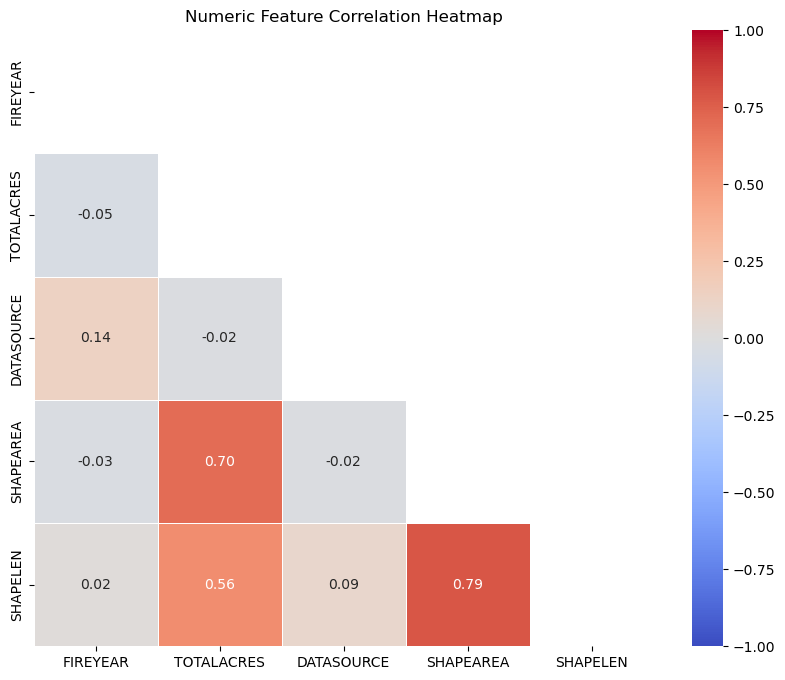

In [63]:
# correlation heatmap for numeric features
num_df = temp_num if 'temp_num' in globals() else df.select_dtypes(include=[np.number])
corr = num_df.corr()

plt.figure(figsize=(10,8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Numeric Feature Correlation Heatmap")
plt.show()

The analysis shows that shape/area metrics drive the signal in the dataset: SHAPEAREA and GISACRES are effectively duplicates (near‑perfect correlation) and SHAPELEN (perimeter) is strongly correlated with those area measures. Correlation matrices and pairwise scans identify these relationships clearly and highlight a moderate association between SHAPELEN and TOTALACRES as well. Several identifier and sparse fields (e.g., OBJECTID, ACCURACY, DBSOURCEID, COMMENTS) produce spurious or dataset‑artifact correlations and should not be treated as causal predictors.

Modeling experiments reinforce the correlation analysis. Decision tree regressors and ensemble models place most importance on area features, and iterative VIF filtering removed redundant predictors to reduce multicollinearity. Cross‑validation shows moderate predictive performance but notable sensitivity to preprocessing choices; imputation of missing numerics, removal of outliers (including negative/implausible perimeters), and deduplication materially affect reported R2 and RMSE. This indicates models can predict perimeter length from area-derived metrics but are vulnerable to overfitting if redundancies remain.

Practical recommendations are to remove or merge derived duplicates (keep either SHAPEAREA or GISACRES), drop sparse/free-text identifiers or treat them separately, and perform domain-aware outlier handling before final modeling. Use cross‑validation, regularized linear models or shallow trees, and monitor VIF for remaining multicollinearity. Finally, validate any deployed predictor with subject‑matter review and holdout data to ensure robust, operationally safe perimeter estimates.

# one final model output

In [70]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Final run: Decision Tree, Random Forest, Gradient Boosting, Linear Regression (repeat models)

# select data (prefer X_use/y_use, then X_full/y_full, then temp_num/target)
if 'X_use' in globals() and globals().get('X_use') is not None and globals().get('y_use') is not None:
    X, y = X_use.copy(), y_use.copy()
elif 'X_full' in globals() and globals().get('X_full') is not None and globals().get('y_full') is not None:
    X, y = X_full.copy(), y_full.copy()
elif 'temp_num' in globals() and isinstance(temp_num, pd.DataFrame) and target in temp_num.columns:
    X = temp_num.drop(columns=[target], errors='ignore').copy()
    y = temp_num[target].copy()
else:
    raise RuntimeError("No feature/target dataset available for modeling.")

X = X.fillna(X.mean())
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'DecisionTree(d=5)': DecisionTreeRegressor(max_depth=5, random_state=42),
    'RandomForest(n=200,d=7)': RandomForestRegressor(n_estimators=200, max_depth=7, random_state=42, n_jobs=-1),
    'GradientBoosting(n=200,lr=0.05)': GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42),
    'LinearRegression': make_pipeline(StandardScaler(), LinearRegression())
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    cv_r2 = cross_val_score(model, X, y, cv=5, scoring='r2', n_jobs=-1).mean()
    results[name] = {'mse': mse, 'r2': r2, 'cv_r2': cv_r2}
    print(f"{name}: MSE={mse:.6f}, R2={r2:.4f}, 5-fold CV R2={cv_r2:.4f}")
    # feature importances / coefficients
    if hasattr(model, "feature_importances_"):
        fi = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
        print(" Top features:\n", fi.head(10).round(4).to_string())
    elif hasattr(model, "named_steps") and 'linearregression' in model.named_steps:
        lr = model.named_steps['linearregression']
        coefs = pd.Series(lr.coef_, index=X.columns).sort_values(key=abs, ascending=False)
        print(" Top coeffs:\n", coefs.head(10).round(6).to_string())
    print()

DecisionTree(d=5): MSE=0.029007, R2=0.7375, 5-fold CV R2=0.6930
 Top features:
 TOTALACRES    0.5754
SHAPEAREA     0.3450
FIREYEAR      0.0566
DATASOURCE    0.0230

RandomForest(n=200,d=7): MSE=0.022295, R2=0.7983, 5-fold CV R2=0.7438
 Top features:
 SHAPEAREA     0.6833
TOTALACRES    0.2191
DATASOURCE    0.0505
FIREYEAR      0.0470

GradientBoosting(n=200,lr=0.05): MSE=0.031106, R2=0.7185, 5-fold CV R2=0.7039
 Top features:
 SHAPEAREA     0.6819
TOTALACRES    0.2087
FIREYEAR      0.0571
DATASOURCE    0.0523

LinearRegression: MSE=0.043523, R2=0.6062, 5-fold CV R2=0.3388
 Top coeffs:
 SHAPEAREA     0.299670
DATASOURCE    0.034007
FIREYEAR      0.010677
TOTALACRES    0.001262



Tree depth: 5 leaves: 28


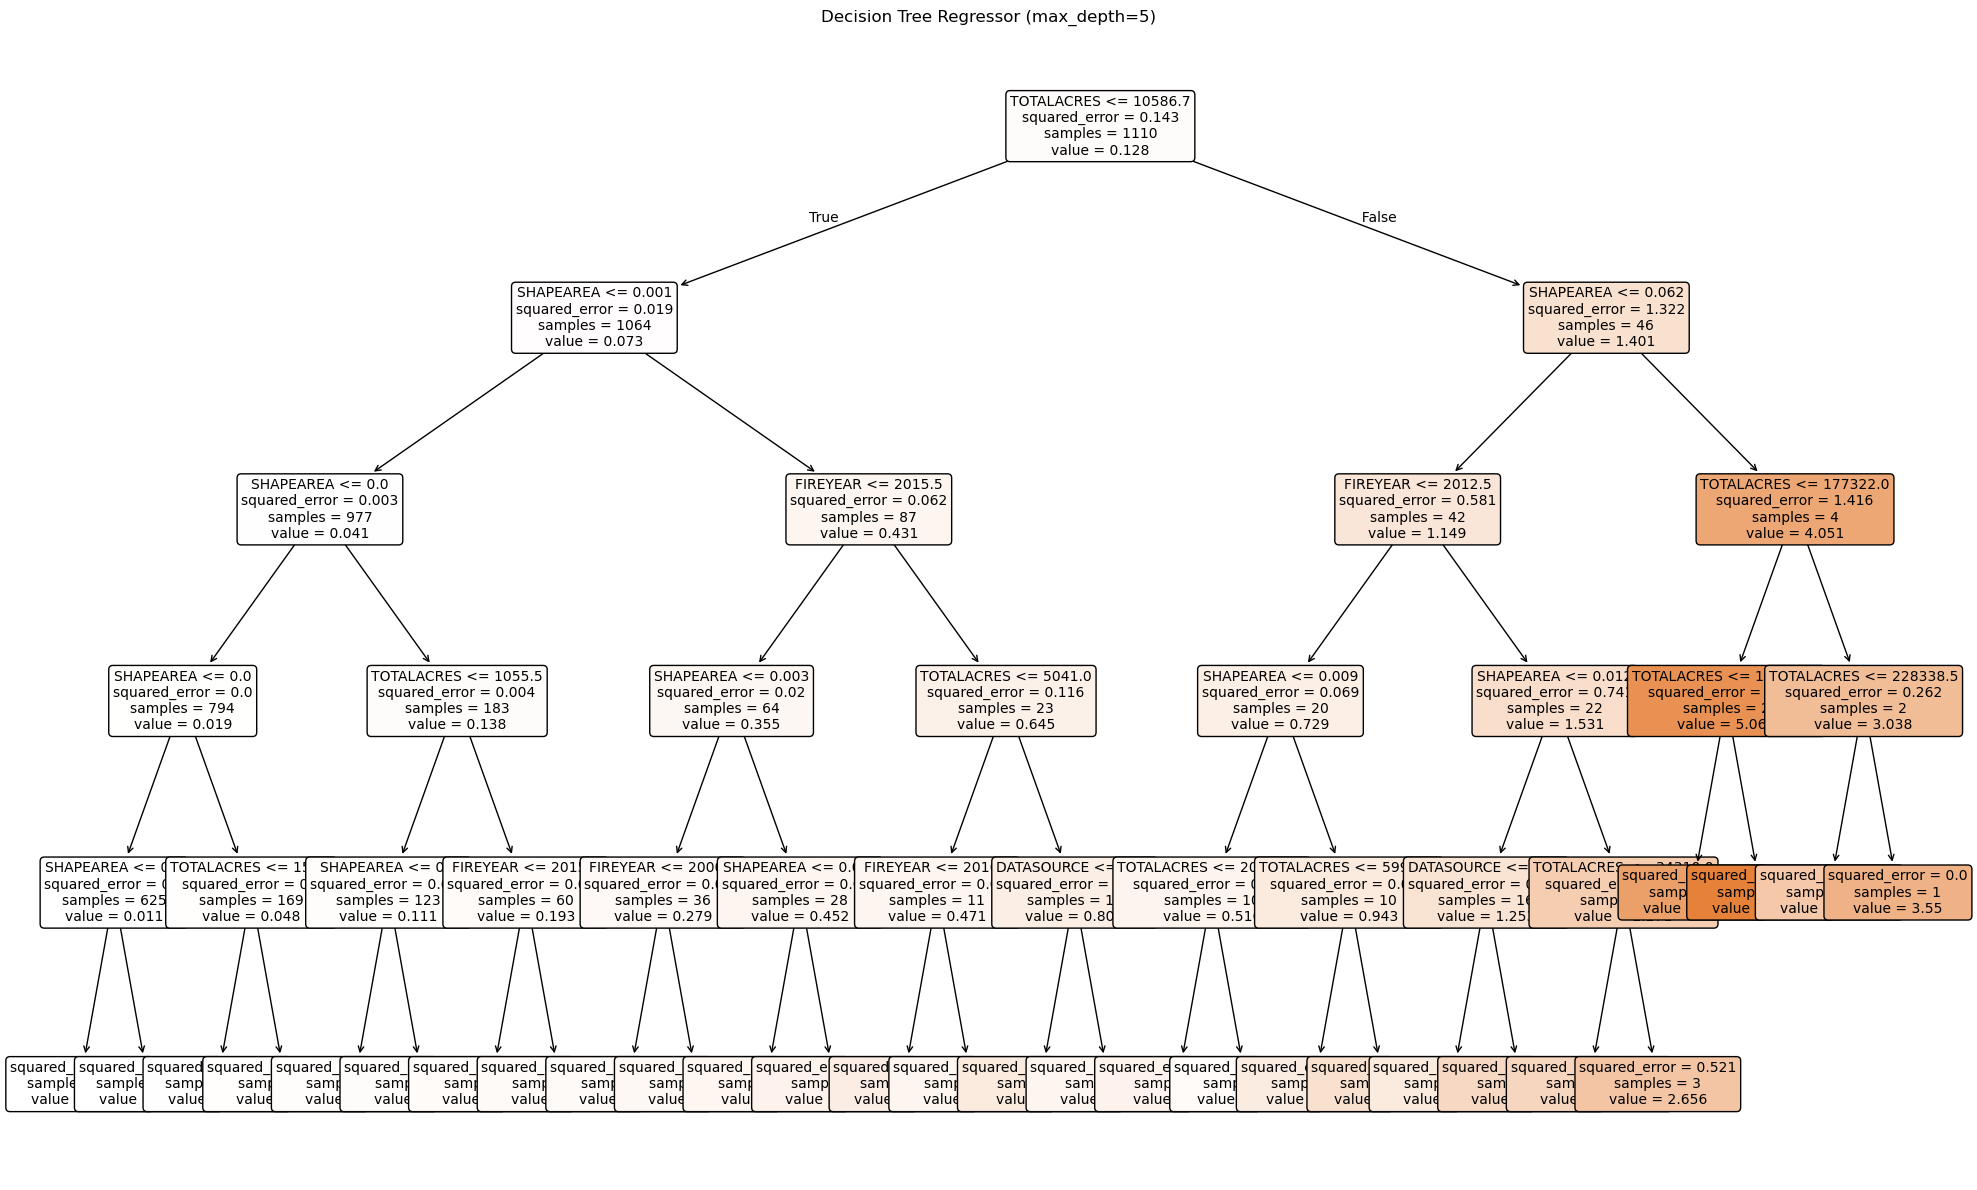

In [71]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split

# train and plot a Decision Tree regressor (saves to decision_tree.png)
import matplotlib.pyplot as plt

# select dataset
if 'X_use' in globals() and globals().get('y_use') is not None:
    X = X_use.copy(); y = y_use.copy()
elif 'X_full' in globals() and globals().get('y_full') is not None:
    X = X_full.copy(); y = y_full.copy()
elif 'temp_num' in globals() and target in temp_num.columns:
    X = temp_num.drop(columns=[target], errors='ignore').copy(); y = temp_num[target].copy()
else:
    raise RuntimeError("No suitable X/y found for modeling.")

X = X.fillna(X.mean())

# train/test split (use existing split if available)
if 'X_train' in globals() and 'y_train' in globals():
    X_tr, y_tr = X_train, y_train
else:
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

# fit tree
dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_tr, y_tr)

# print simple stats
print("Tree depth:", dt.get_depth(), "leaves:", dt.get_n_leaves())

# plot and save
plt.figure(figsize=(20,12))
plot_tree(dt, feature_names=list(X.columns), filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree Regressor (max_depth=5)")
plt.tight_layout()
plt.savefig("decision_tree.png", dpi=150, bbox_inches="tight")
plt.show()